# Spellcheck Comparison Analysis (Cross-Algorithm)

Compares the two main spellcheck methods (pyspellchecker, n-gram perplexity)
across all three vocabulary strategies (original, B, C), for **both extraction
algorithms** (legacy, new). Plus a separate analysis section for the
systematic patterns mined from n-gram flags.

## Why three comparisons

1. **Method agreement**: for each strategy and algorithm, do pyspellchecker
   and n-gram flag the same tokens? When they disagree, which method catches
   what? Answers: are these methods complementary or redundant?

2. **Strategy effect**: for each method and algorithm, how does flag rate
   change across strategies? Which tokens move between "known" and "unknown"
   as we tighten the vocabulary? Answers: does tier filtering reduce noise
   or just shrink coverage?

3. **Tier alignment (legacy algorithm only)**: for each method × strategy
   combination, does the per-dict flag rate correlate with the dict's
   structural quality tier (from sanity check)? Tiers and vocabularies
   were both derived from the legacy algorithm's output, so this analysis
   is only methodologically defensible for legacy. The new algorithm
   is reported on flag rates and method agreement but excluded from tier
   alignment.

## Why include patterns separately

The pattern miner is a post-hoc analysis of n-gram flags, not a parallel
flagger. Treating it as a comparable method would be circular (it's mined
from n-gram output, so by construction it agrees with n-gram). Instead, §6
dedicates a narrative section to the patterns themselves: which systematic
error families explain the n-gram flags?

## Inputs

This notebook consumes outputs from:
- `PostProcessing pyspellchecker v2.ipynb` × 3 strategies × 2 algorithms
- `Indonesian Spellcheck Ngram.ipynb` × 3 strategies × 2 algorithms
- `Indonesian Spellcheck Patterns.ipynb` × 3 strategies × 2 algorithms
- `Distribution Sanity Checks v4.ipynb` (legacy only; for parcor tier classification)

## Cross-algorithm scope

To make cross-algorithm comparisons fair, only dictionaries covered by both
algorithms are included in the analyses (68 dicts: the legacy set). The 14
dictionaries unique to the new algorithm are excluded from cross-algo
comparison but exist in raw spellcheck outputs.

## Outputs

All in `../csvAnalysis/spellcheck_comparison/`:
- `_method_agreement_per_strategy.csv`: agreement counts per (strategy, algo)
- `_method_agreement.png`: six-panel breakdown chart
- `_strategy_effect_per_method.csv`: flag rate distributions per (method, algo, strategy)
- `_strategy_effect.png`: four-panel parallel-coordinates plot
- `_tier_alignment_per_pair.csv`: flag rate × tier correlations (legacy only)
- `_tier_alignment.png`: six-panel box plot grid (legacy only)
- `_systematic_patterns_summary.csv`: top patterns with explained-token counts (per algo)
- `_examples_*.csv`: qualitative example tables for each comparison

## 1. Configuration and paths

In [9]:
import os
import re
from pathlib import Path
from collections import Counter, defaultdict
from itertools import product

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Strategies, methods, algorithms to analyze
STRATEGIES = ["dict_strategy_original", "dict_strategy_b", "dict_strategy_c"]
METHODS    = ["pyspell", "ngram"]
ALGOS      = ["legacy", "new"]

# Path roots — per algorithm
PYSPELL_ROOTS = {
    "legacy": Path("../Ekstraksi/12. Parallel Corpus - Spellcheck Detection"),
    "new":    Path("../Ekstraksi/12. (New) Parallel Corpus - Spellcheck Detection"),
}
NGRAM_ROOTS = {
    "legacy": Path("../Ekstraksi/12. Parallel Corpus - Spellcheck Ngram"),
    "new":    Path("../Ekstraksi/12. (New) Parallel Corpus - Spellcheck Ngram"),
}

# Sanity tier file (legacy only — by design)
SANITY_TIERS = Path("../csvAnalysis/sanity_v4_1/_quality_tiers.csv")

DST_DIR = Path("../csvAnalysis/spellcheck_comparison2/")
DST_DIR.mkdir(parents=True, exist_ok=True)

# Friendly display names
STRATEGY_DISPLAY = {"dict_strategy_original": "Original", "dict_strategy_b": "Strategy B", "dict_strategy_c": "Strategy C"}
METHOD_DISPLAY   = {"pyspell": "pyspellchecker", "ngram": "n-gram perplexity"}
ALGO_DISPLAY     = {"legacy": "Legacy algo", "new": "New algo"}

# Cross-algo scope: only dicts present in the legacy tier file (= 68 shared dicts)
# are used for cross-algo comparison. New-algo-only dicts get excluded.
_tiers_for_scope = pd.read_csv(SANITY_TIERS, dtype={"dict_id": str})
SHARED_DICT_IDS = set(_tiers_for_scope["dict_id"].astype(str))
print(f"Shared dict scope: {len(SHARED_DICT_IDS)} dicts (from legacy tier file)")

# Verify inputs exist
print("\nInput availability check:")
for algo in ALGOS:
    print(f"\n  [{algo}]")
    for s in STRATEGIES:
        py_dir = PYSPELL_ROOTS[algo] / s
        ng_dir = NGRAM_ROOTS[algo] / s
        print(f"    {s}:")
        print(f"      pyspell:  {'✓' if py_dir.exists() else '✗'}  {py_dir}")
        print(f"      ngram:    {'✓' if ng_dir.exists() else '✗'}  {ng_dir}")

print(f"\n  sanity tiers: {'✓' if SANITY_TIERS.exists() else '✗'}  {SANITY_TIERS}")
print(f"\nOutput dir:    {DST_DIR.resolve()}")

Shared dict scope: 68 dicts (from legacy tier file)

Input availability check:

  [legacy]
    dict_strategy_original:
      pyspell:  ✓  ..\Ekstraksi\12. Parallel Corpus - Spellcheck Detection\dict_strategy_original
      ngram:    ✓  ..\Ekstraksi\12. Parallel Corpus - Spellcheck Ngram\dict_strategy_original
    dict_strategy_b:
      pyspell:  ✓  ..\Ekstraksi\12. Parallel Corpus - Spellcheck Detection\dict_strategy_b
      ngram:    ✓  ..\Ekstraksi\12. Parallel Corpus - Spellcheck Ngram\dict_strategy_b
    dict_strategy_c:
      pyspell:  ✓  ..\Ekstraksi\12. Parallel Corpus - Spellcheck Detection\dict_strategy_c
      ngram:    ✓  ..\Ekstraksi\12. Parallel Corpus - Spellcheck Ngram\dict_strategy_c

  [new]
    dict_strategy_original:
      pyspell:  ✓  ..\Ekstraksi\12. (New) Parallel Corpus - Spellcheck Detection\dict_strategy_original
      ngram:    ✓  ..\Ekstraksi\12. (New) Parallel Corpus - Spellcheck Ngram\dict_strategy_original
    dict_strategy_b:
      pyspell:  ✓  ..\Ekstrak

## 2. Load aligned per-dict aggregates

Build a single long-format dataframe with columns:
`dict_id`, `method`, `strategy`, `total_tokens`, `flagged_count`, `flag_rate`.

We work with per-dict aggregates (small, fast) and only load per-token detail
when we need example tokens for qualitative analysis.

In [10]:
def load_pyspell_aggregate(algo: str, strategy: str) -> pd.DataFrame:
    """Returns DataFrame with: dict_id, total_tokens, flagged_count, flag_rate."""
    per_dict_path = PYSPELL_ROOTS[algo] / strategy / "_per_dict_summary.csv"
    if not per_dict_path.exists():
        return pd.DataFrame()
    df = pd.read_csv(per_dict_path, dtype={"dict_id": str})
    return pd.DataFrame({
        "dict_id":       df["dict_id"],
        "total_tokens":  df["total_tokens"],
        "flagged_count": df["total_unknown"],
        "flag_rate":     df["unknown_rate"],
    })


def load_ngram_aggregate(algo: str, strategy: str) -> pd.DataFrame:
    """Returns DataFrame with: dict_id, total_tokens, flagged_count, flag_rate."""
    per_dict_path = NGRAM_ROOTS[algo] / strategy / "_per_dict_summary.csv"
    if not per_dict_path.exists():
        return pd.DataFrame()
    df = pd.read_csv(per_dict_path, dtype={"dict_id": str})
    return pd.DataFrame({
        "dict_id":       df["dict_id"],
        "total_tokens":  df["total_tokens"],
        "flagged_count": df["total_flagged"],
        "flag_rate":     df["flag_rate"],
    })


loaders = {"pyspell": load_pyspell_aggregate, "ngram": load_ngram_aggregate}

rows = []
for algo, method, strategy in product(ALGOS, METHODS, STRATEGIES):
    df = loaders[method](algo, strategy)
    if df.empty:
        print(f"  ⚠ Missing: algo={algo}, method={method}, strategy={strategy}")
        continue
    df["algo"]     = algo
    df["method"]   = method
    df["strategy"] = strategy
    rows.append(df)

aggregates_full = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

# Filter to the shared dict scope (68 dicts present in both algos via legacy tier file)
aggregates = aggregates_full[aggregates_full["dict_id"].isin(SHARED_DICT_IDS)].copy()

print(f"\nLoaded aggregates (all): {len(aggregates_full):,} rows")
print(f"Filtered to shared dicts: {len(aggregates):,} rows")
print(f"  Algos: {sorted(aggregates['algo'].unique())}")
print(f"  Methods: {sorted(aggregates['method'].unique())}")
print(f"  Strategies: {sorted(aggregates['strategy'].unique())}")
print(f"  Dicts: {aggregates['dict_id'].nunique()}")
aggregates.head(8)


Loaded aggregates (all): 894 rows
Filtered to shared dicts: 810 rows
  Algos: ['legacy', 'new']
  Methods: ['ngram', 'pyspell']
  Strategies: ['dict_strategy_b', 'dict_strategy_c', 'dict_strategy_original']
  Dicts: 68


,dict_id,total_tokens,flagged_count,flag_rate,algo,method,strategy
0,1,22573,0,0.000000,legacy,pyspell,dict_strategy_original
1,2,19699,0,0.000000,legacy,pyspell,dict_strategy_original
2,3,34506,1,0.000029,legacy,pyspell,dict_strategy_original
3,4,17052,0,0.000000,legacy,pyspell,dict_strategy_original
4,5,1803,0,0.000000,legacy,pyspell,dict_strategy_original
5,8,5920,0,0.000000,legacy,pyspell,dict_strategy_original
6,9,10158,0,0.000000,legacy,pyspell,dict_strategy_original
7,10,16472,0,0.000000,legacy,pyspell,dict_strategy_original


## 3. Join with sanity check tiers

In [11]:
tiers_df = pd.read_csv(SANITY_TIERS, dtype={"dict_id": str})
# Use parcor_tier_final because spellcheck operates on parcor content
# (consistent with the vocab builder's filter)
tier_map = dict(zip(tiers_df["dict_id"], tiers_df["parcor_tier_final"]))

# Apply tier ONLY to legacy rows; new-algo rows get NaN tier and are
# excluded from tier-alignment analysis by design (see Section 1 intro
# for rationale: tiers derived from legacy output)
def _assign_tier(row):
    if row["algo"] == "legacy":
        return tier_map.get(row["dict_id"])
    return np.nan

aggregates["tier"] = aggregates.apply(_assign_tier, axis=1)

print(f"Total rows: {len(aggregates)}")
print(f"Legacy rows: {(aggregates['algo'] == 'legacy').sum()}")
print(f"  With tier:   {aggregates[aggregates['algo'] == 'legacy']['tier'].notna().sum()}")
print(f"New rows:    {(aggregates['algo'] == 'new').sum()}")
print(f"  With tier:   {aggregates[aggregates['algo'] == 'new']['tier'].notna().sum()} (expected 0)")

print(f"\nLegacy tier distribution:")
print(aggregates[aggregates["algo"] == "legacy"]["tier"].value_counts())

Total rows: 810
Legacy rows: 408
  With tier:   408
New rows:    402
  With tier:   0 (expected 0)

Legacy tier distribution:
tier
needs_attention    258
good                84
broken              66
Name: count, dtype: int64


## 4. Comparison 1 (Method agreement, per (strategy × algorithm))

For each (strategy, algorithm) pair, do pyspellchecker and n-gram flag the
same tokens? Cross-algorithm comparison reveals whether the two methods'
agreement depends on the algorithm's output quality.

In [12]:
def load_pyspell_flagged_tokens(algo: str, strategy: str) -> set:
    path = PYSPELL_ROOTS[algo] / strategy / "_top_unknown_tokens.csv"
    if not path.exists():
        return set()
    df = pd.read_csv(path)
    return set(df["token"].astype(str).str.lower())


def load_ngram_flagged_tokens(algo: str, strategy: str) -> set:
    path = NGRAM_ROOTS[algo] / strategy / "_top_suspicious_tokens.csv"
    if not path.exists():
        return set()
    df = pd.read_csv(path)
    return set(df["token"].astype(str).str.lower())


agreement_rows = []
flag_sets = {}  # cache for §5, keyed by (strategy, method, algo)

for algo in ALGOS:
    for strategy in STRATEGIES:
        py_set = load_pyspell_flagged_tokens(algo, strategy)
        ng_set = load_ngram_flagged_tokens(algo, strategy)

        flag_sets[(strategy, "pyspell", algo)] = py_set
        flag_sets[(strategy, "ngram",   algo)] = ng_set

        both    = py_set & ng_set
        only_py = py_set - ng_set
        only_ng = ng_set - py_set
        union   = py_set | ng_set

        agreement_rows.append({
            "algo":           algo,
            "strategy":       strategy,
            "n_pyspell":      len(py_set),
            "n_ngram":        len(ng_set),
            "n_both":         len(both),
            "n_pyspell_only": len(only_py),
            "n_ngram_only":   len(only_ng),
            "n_union":        len(union),
            "jaccard":        len(both) / len(union) if union else 0.0,
        })

agreement_df = pd.DataFrame(agreement_rows)
agreement_df.to_csv(DST_DIR / "_method_agreement_per_strategy.csv", index=False)
print("=== Method Agreement Per (Strategy, Algo) ===")
print(agreement_df.to_string(index=False))

=== Method Agreement Per (Strategy, Algo) ===
  algo               strategy  n_pyspell  n_ngram  n_both  n_pyspell_only  n_ngram_only  n_union  jaccard
legacy dict_strategy_original          0      200       0               0           200      200 0.000000
legacy        dict_strategy_b        100      200      22              78           178      278 0.079137
legacy        dict_strategy_c        100      200      39              61           161      261 0.149425
   new dict_strategy_original        100      200       7              93           193      293 0.023891
   new        dict_strategy_b        100      200      10              90           190      290 0.034483
   new        dict_strategy_c        100      200      43              57           157      257 0.167315


### 4.1 Six-panel agreement breakdown chart (3 strategies × 2 algorithms)

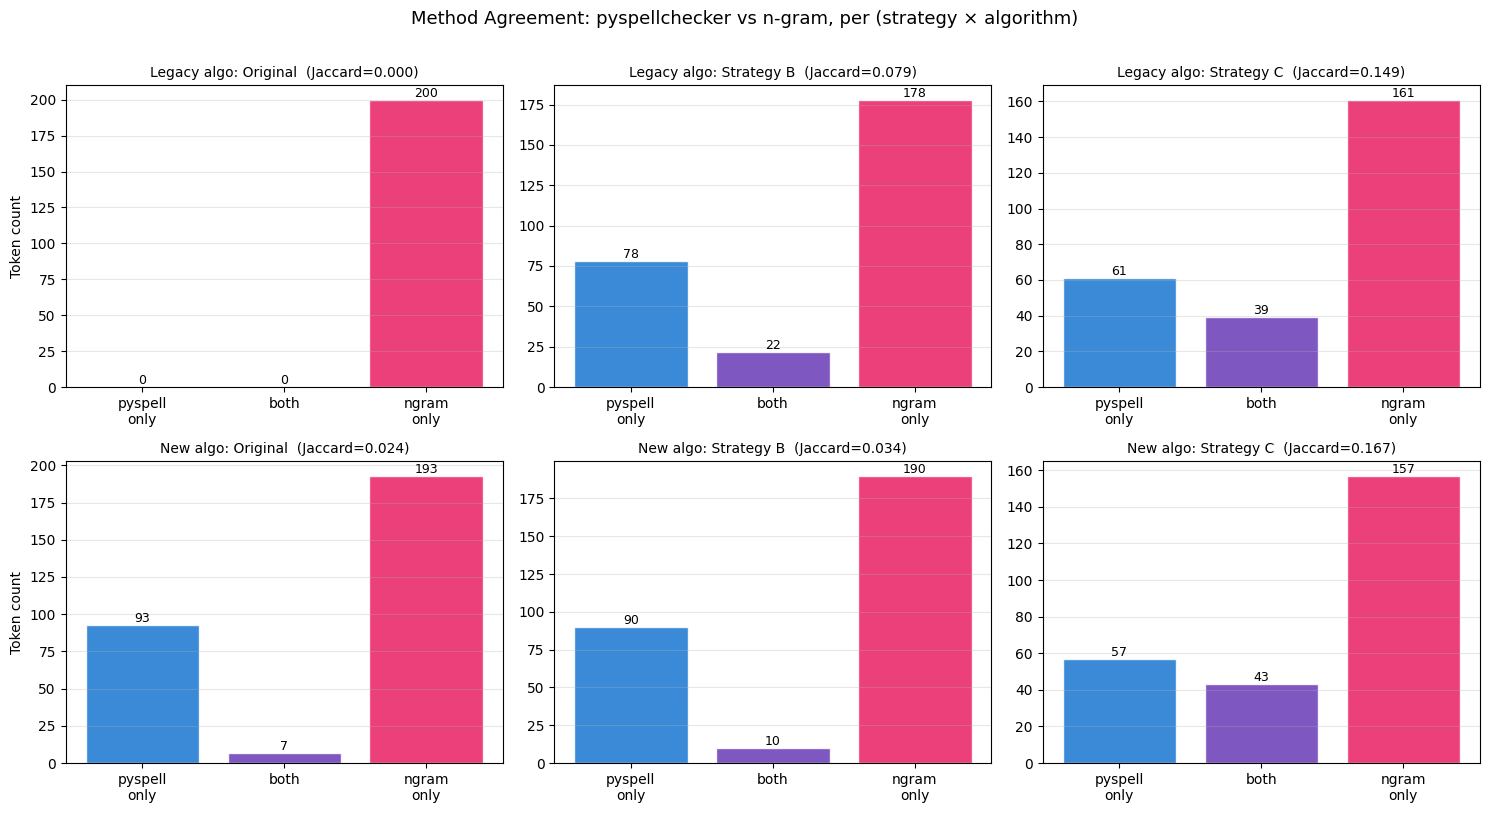

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)

for row_idx, algo in enumerate(ALGOS):
    for col_idx, strategy in enumerate(STRATEGIES):
        ax = axes[row_idx, col_idx]
        r = agreement_df[(agreement_df["algo"] == algo)
                          & (agreement_df["strategy"] == strategy)]
        if r.empty:
            ax.text(0.5, 0.5, "(data missing)", ha="center", va="center",
                    transform=ax.transAxes)
            ax.set_title(f"{ALGO_DISPLAY[algo]}: {STRATEGY_DISPLAY[strategy]}",
                         fontsize=10)
            continue
        r = r.iloc[0]

        categories = ["pyspell\nonly", "both", "ngram\nonly"]
        values     = [r["n_pyspell_only"], r["n_both"], r["n_ngram_only"]]
        colors     = ["#1976d2", "#673ab7", "#e91e63"]

        bars = ax.bar(categories, values, color=colors, alpha=0.85, edgecolor="white", linewidth=1)
        for bar, v in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{int(v):,}", ha="center", va="bottom", fontsize=9)

        ax.set_title(f"{ALGO_DISPLAY[algo]}: {STRATEGY_DISPLAY[strategy]}  "
                     f"(Jaccard={r['jaccard']:.3f})", fontsize=10)
        ax.set_ylabel("Token count" if col_idx == 0 else "")
        ax.grid(alpha=0.3, axis="y")

plt.suptitle("Method Agreement: pyspellchecker vs n-gram, per (strategy × algorithm)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(DST_DIR / "_method_agreement.png", dpi=120, bbox_inches="tight")
plt.show()

### 4.2 Example tokens per agreement category

In [14]:
example_rows = []
for algo in ALGOS:
    for strategy in STRATEGIES:
        py_set = flag_sets.get((strategy, "pyspell", algo), set())
        ng_set = flag_sets.get((strategy, "ngram",   algo), set())
        if not py_set and not ng_set:
            continue

        both    = sorted(py_set & ng_set)[:15]
        only_py = sorted(py_set - ng_set)[:15]
        only_ng = sorted(ng_set - py_set)[:15]

        for token in both:
            example_rows.append({"algo": algo, "strategy": strategy, "category": "both", "token": token})
        for token in only_py:
            example_rows.append({"algo": algo, "strategy": strategy, "category": "pyspell_only", "token": token})
        for token in only_ng:
            example_rows.append({"algo": algo, "strategy": strategy, "category": "ngram_only", "token": token})

examples_df = pd.DataFrame(example_rows)
examples_df.to_csv(DST_DIR / "_examples_method_agreement.csv", index=False)
print(f"Saved {len(examples_df)} example rows for qualitative inspection")
print(f"\n=== Sample: tokens flagged by BOTH methods (Strategy C, legacy algo) ===")
both_legacy_c = examples_df[(examples_df["strategy"] == "strategy_C")
                            & (examples_df["category"] == "both")
                            & (examples_df["algo"] == "legacy")].head(10)
print(both_legacy_c.to_string(index=False))

Saved 227 example rows for qualitative inspection

=== Sample: tokens flagged by BOTH methods (Strategy C, legacy algo) ===
Empty DataFrame
Columns: [algo, strategy, category, token]
Index: []


## 5. Comparison 2 (Strategy effect, per (method × algorithm))

For each (method, algorithm) pair, how does the choice of vocabulary
strategy affect per-dict flag rate? Cross-algorithm view shows whether the
strategies have consistent effects across both extraction algorithms.

Each panel below is a parallel-coordinates plot: each line is one
dictionary, with the line traversing the three strategy x-positions. The
line's slope reveals whether that dict's flag rate increased or decreased
when the vocabulary tightened. Lines are colored by parcor tier for the
legacy panels; new-algo panels are colored gray since tier labels apply
only to the legacy algorithm.

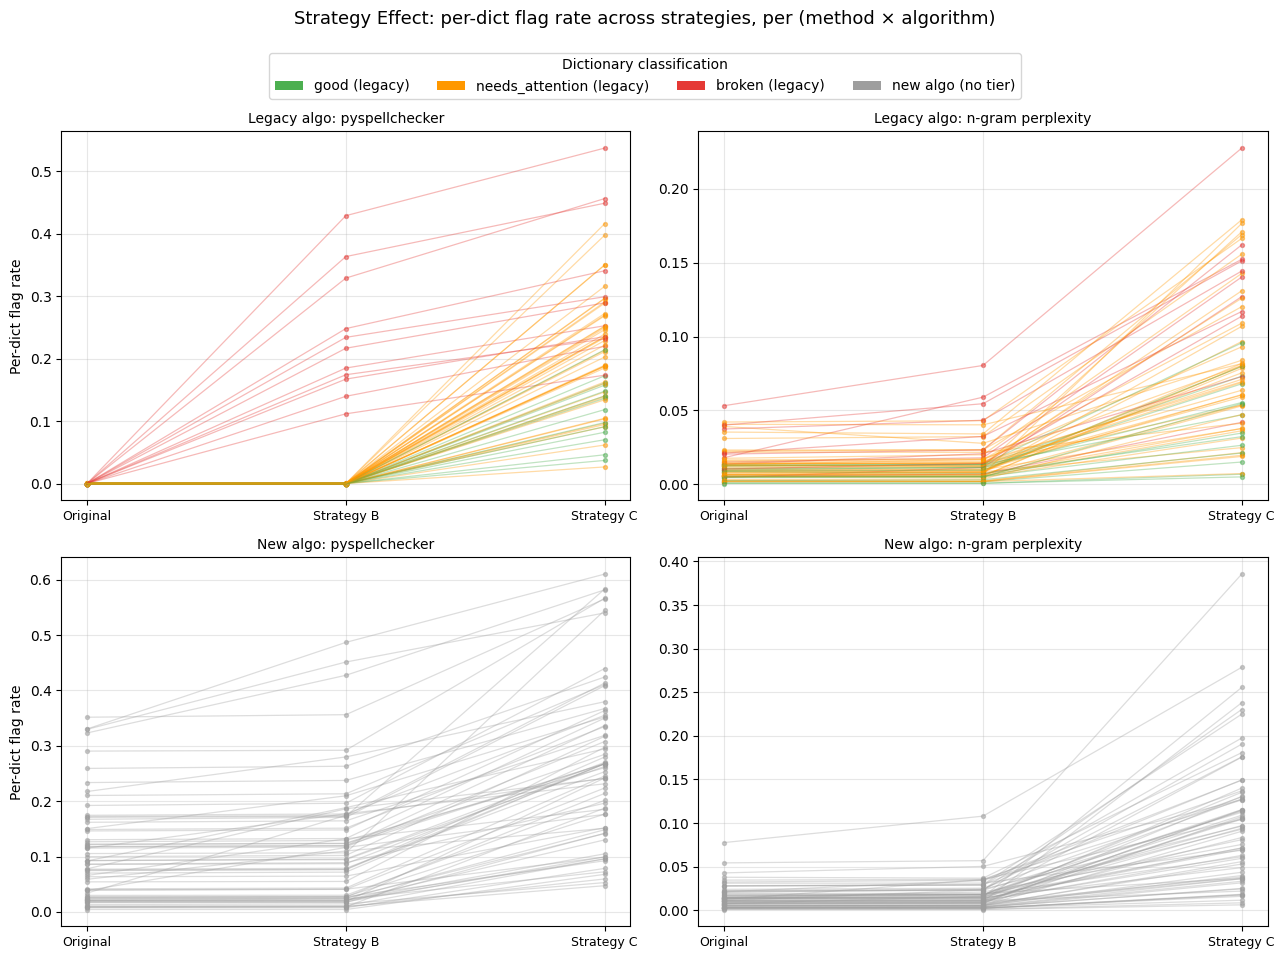

In [15]:
tier_colors = {
    "good":            "#4caf50",
    "needs_attention": "#ff9800",
    "broken":          "#e53935",
    "not_applicable":  "#9e9e9e",
}
NEW_ALGO_COLOR = "#9e9e9e"

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=False)

for row_idx, algo in enumerate(ALGOS):
    for col_idx, method in enumerate(METHODS):
        ax = axes[row_idx, col_idx]
        sub = aggregates[(aggregates["algo"] == algo)
                          & (aggregates["method"] == method)]
        if sub.empty:
            ax.text(0.5, 0.5, "(data missing)", ha="center", va="center",
                    transform=ax.transAxes)
            ax.set_title(f"{ALGO_DISPLAY[algo]}: {METHOD_DISPLAY[method]}",
                         fontsize=10)
            continue

        # Pivot so we have one row per dict, columns = strategies, values = flag_rate
        pivot = sub.pivot_table(index="dict_id", columns="strategy",
                                 values="flag_rate", aggfunc="first")
        # Reindex columns to keep order consistent
        cols_present = [s for s in STRATEGIES if s in pivot.columns]
        pivot = pivot[cols_present]

        # Join tier info (for legacy panels)
        if algo == "legacy":
            tier_per_dict = sub.drop_duplicates("dict_id").set_index("dict_id")["tier"]
        else:
            tier_per_dict = None

        # Plot each dict as a line across strategies
        x_positions = list(range(len(cols_present)))
        for dict_id, row in pivot.iterrows():
            y = row.values
            if algo == "legacy" and tier_per_dict is not None:
                tier = tier_per_dict.get(dict_id, "not_applicable")
                color = tier_colors.get(tier, "#9e9e9e")
            else:
                color = NEW_ALGO_COLOR
            ax.plot(x_positions, y, color=color, alpha=0.35, linewidth=0.9)
            ax.scatter(x_positions, y, color=color, s=8, alpha=0.5)

        ax.set_xticks(x_positions)
        ax.set_xticklabels([STRATEGY_DISPLAY[s] for s in cols_present], fontsize=9)
        ax.set_title(f"{ALGO_DISPLAY[algo]}: {METHOD_DISPLAY[method]}", fontsize=10)
        ax.set_ylabel("Per-dict flag rate" if col_idx == 0 else "")
        ax.grid(alpha=0.3)

# Legend (tier colors) shown once
legend_elements = [
    Patch(facecolor=tier_colors["good"], label="good (legacy)"),
    Patch(facecolor=tier_colors["needs_attention"], label="needs_attention (legacy)"),
    Patch(facecolor=tier_colors["broken"], label="broken (legacy)"),
    Patch(facecolor=NEW_ALGO_COLOR, label="new algo (no tier)"),
]
fig.legend(handles=legend_elements, loc="upper center", ncol=4,
           bbox_to_anchor=(0.5, 1.02), fontsize=10, title="Dictionary classification")

plt.suptitle("Strategy Effect: per-dict flag rate across strategies, per (method × algorithm)",
             fontsize=13, y=1.06)
plt.tight_layout()
plt.savefig(DST_DIR / "_strategy_effect.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.1 Strategy effect summary table

In [16]:
strategy_effect_rows = []
for algo in ALGOS:
    for method in METHODS:
        method_data = aggregates[(aggregates["algo"] == algo)
                                  & (aggregates["method"] == method)]
        for strategy in STRATEGIES:
            s_data = method_data[method_data["strategy"] == strategy]
            if s_data.empty:
                continue
            strategy_effect_rows.append({
                "algo":            algo,
                "method":          method,
                "strategy":        strategy,
                "n_dicts":         len(s_data),
                "mean_flag_rate":  round(s_data["flag_rate"].mean(), 4),
                "median_flag_rate": round(s_data["flag_rate"].median(), 4),
                "p95_flag_rate":   round(s_data["flag_rate"].quantile(0.95), 4),
                "total_tokens":    int(s_data["total_tokens"].sum()),
                "total_flagged":   int(s_data["flagged_count"].sum()),
            })
strategy_effect_df = pd.DataFrame(strategy_effect_rows)
strategy_effect_df.to_csv(DST_DIR / "_strategy_effect_per_method.csv", index=False)
print("=== Strategy Effect Per (Algo, Method, Strategy) ===")
print(strategy_effect_df.to_string(index=False))

=== Strategy Effect Per (Algo, Method, Strategy) ===
  algo  method               strategy  n_dicts  mean_flag_rate  median_flag_rate  p95_flag_rate  total_tokens  total_flagged
legacy pyspell dict_strategy_original       68          0.0000            0.0000         0.0000       1434567              9
legacy pyspell        dict_strategy_b       68          0.0382            0.0000         0.2431       1434567          28767
legacy pyspell        dict_strategy_c       68          0.2114            0.2122         0.4094       1434567         305903
legacy   ngram dict_strategy_original       68          0.0135            0.0106         0.0398       1434567          18503
legacy   ngram        dict_strategy_b       68          0.0155            0.0116         0.0433       1434567          21132
legacy   ngram        dict_strategy_c       68          0.0822            0.0730         0.1701       1434567         120006
   new pyspell dict_strategy_original       67          0.1019          

### 5.2 Tokens that moved between strategies

In [17]:
movement_rows = []
for algo in ALGOS:
    for method in METHODS:
        s_orig = flag_sets.get((STRATEGIES[0], method, algo), set())
        s_b    = flag_sets.get(("strategy_B",  method, algo), set())
        s_c    = flag_sets.get(("strategy_C",  method, algo), set())

        new_in_c     = sorted(s_c - s_b)[:15]
        new_in_b     = sorted(s_b - s_orig)[:15]
        flagged_only_in_orig = sorted(s_orig - s_b - s_c)[:15]

        for token in new_in_c:
            movement_rows.append({
                "algo": algo, "method": method,
                "movement": "newly_flagged_in_C_vs_B",
                "token": token,
                "interpretation": "Token appears in B's vocab but not C's — a real word C considers too rare, OR a true error C catches",
            })
        for token in new_in_b:
            movement_rows.append({
                "algo": algo, "method": method,
                "movement": "newly_flagged_in_B_vs_original",
                "token": token,
                "interpretation": "Token in original vocab (admitted noise) but excluded from B — likely a noise word B correctly rejects",
            })
        for token in flagged_only_in_orig:
            movement_rows.append({
                "algo": algo, "method": method,
                "movement": "flagged_only_in_original",
                "token": token,
                "interpretation": "Token original method missed but B/C didn't catch — possibly a coverage anomaly in original",
            })

movement_df = pd.DataFrame(movement_rows)
movement_df.to_csv(DST_DIR / "_examples_strategy_movement.csv", index=False)
print(f"Saved {len(movement_df)} movement examples across (algo, method) combinations")

if len(movement_df) and {"algo", "method", "movement"}.issubset(movement_df.columns):
    sample = movement_df[(movement_df["algo"] == "legacy")
                         & (movement_df["method"] == "pyspell")
                         & (movement_df["movement"] == "newly_flagged_in_C_vs_B")].head(10)
    if len(sample):
        print(f"\n=== Sample: tokens newly flagged in C vs B (pyspell, legacy) ===")
        print(sample[["token", "interpretation"]].to_string(index=False))
    else:
        print("(No matching movement examples to display for legacy pyspell C-vs-B)")
else:
    print("(No movement rows generated — flag sets may be empty or identical across strategies)")

Saved 45 movement examples across (algo, method) combinations
(No matching movement examples to display for legacy pyspell C-vs-B)


## 6. Comparison 3 Tier alignment, per method × strategy *(legacy algorithm only)*

For each method × strategy combination, does per-dict flag rate correlate
with the dict's structural tier from sanity check (parcor tier specifically)?
If methods are measuring real quality, broken-tier dicts should have higher
flag rates than good-tier dicts.

### Why legacy only

Both the structural quality tiers (from `sanity_v4_1/_quality_tiers.csv`) and
the spell-check vocabularies (Original, B, C) were derived from the legacy
algorithm's output. Applying tier alignment to the new algorithm's flag
rates would be methodologically muddled: a dict labeled "broken" under
legacy might extract cleanly under the new algorithm, but legacy tiers
would still flag it as broken, making the new-algo tier-flag correlation
hard to interpret.

The new algorithm participates in **flag rate reporting** and **method
agreement** but is excluded from this section. Two outputs
below: box plots grouped by tier (visualization), and Spearman
correlations (single-number summary suitable for thesis tables).

C:\Users\Legion\AppData\Local\Temp\ipykernel_25676\3976990647.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=[t.replace("_", "\n") for t in tier_order],
C:\Users\Legion\AppData\Local\Temp\ipykernel_25676\3976990647.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=[t.replace("_", "\n") for t in tier_order],
C:\Users\Legion\AppData\Local\Temp\ipykernel_25676\3976990647.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=[t.replace("_", "\n") for t in tier_order],
C:\Users\Legion\AppData\Local\Temp\ipykernel_2

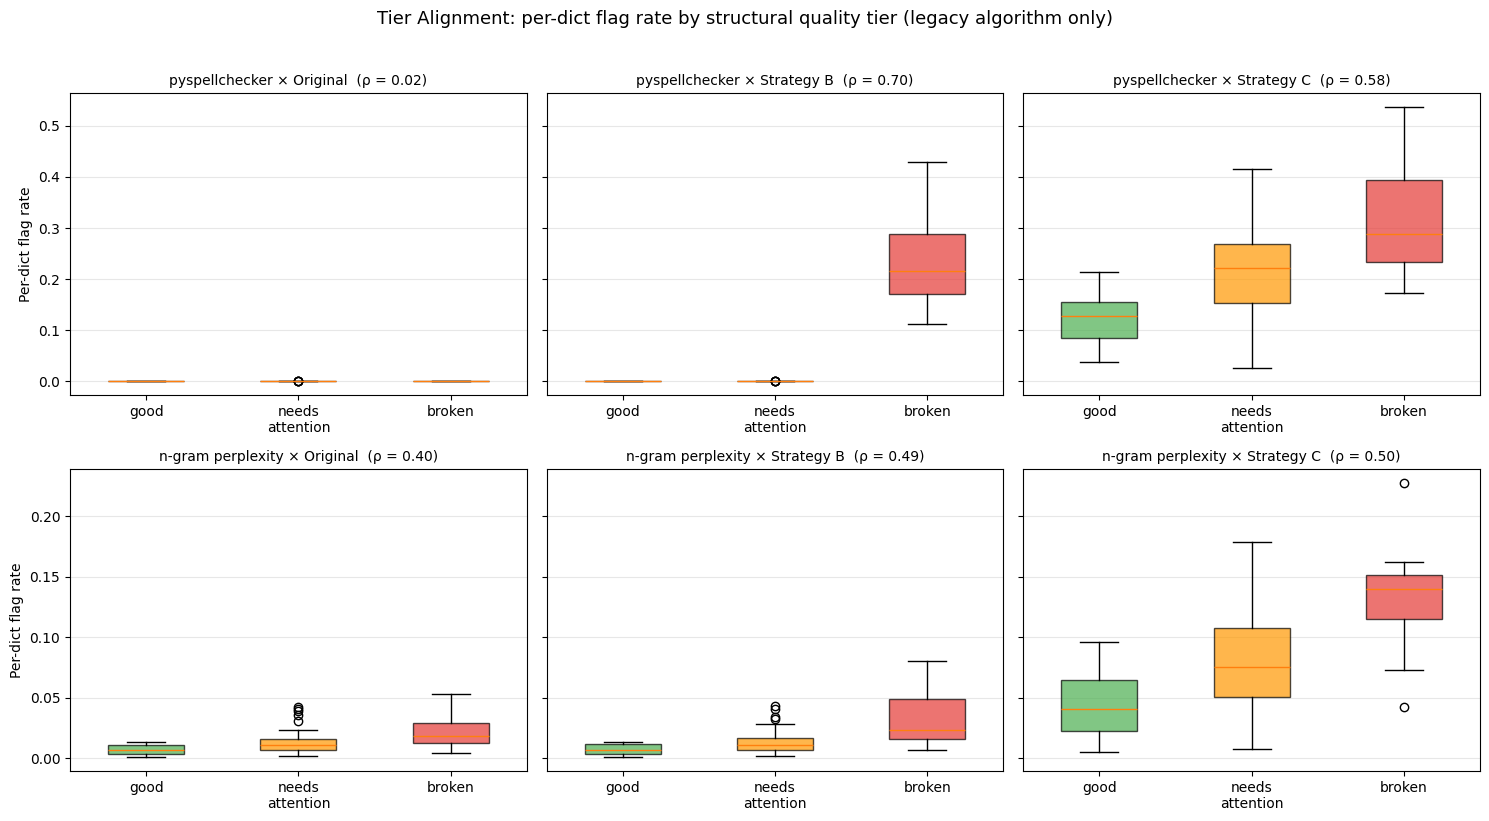


=== Tier-Flag Rate Correlations (Spearman, legacy only) ===
  algo  method               strategy  spearman_rho  p_value  n
legacy pyspell dict_strategy_original         0.022   0.8569 68
legacy pyspell        dict_strategy_b         0.703   0.0000 68
legacy pyspell        dict_strategy_c         0.576   0.0000 68
legacy   ngram dict_strategy_original         0.402   0.0007 68
legacy   ngram        dict_strategy_b         0.488   0.0000 68
legacy   ngram        dict_strategy_c         0.505   0.0000 68


In [18]:
# Filter to legacy only (by design — see §6 intro)
legacy_aggregates = aggregates[aggregates["algo"] == "legacy"].copy()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey="row")

tier_order  = ["good", "needs_attention", "broken"]
tier_colors = {"good": "#4caf50", "needs_attention": "#ff9800", "broken": "#e53935"}

correlation_rows = []

for row_idx, method in enumerate(METHODS):
    for col_idx, strategy in enumerate(STRATEGIES):
        ax = axes[row_idx, col_idx]
        cell_data = legacy_aggregates[
            (legacy_aggregates["method"] == method)
            & (legacy_aggregates["strategy"] == strategy)
            & (legacy_aggregates["tier"].isin(tier_order))
        ]
        if cell_data.empty:
            ax.text(0.5, 0.5, "(no data)", ha="center", va="center",
                    transform=ax.transAxes)
            continue

        plot_data = [cell_data[cell_data["tier"] == t]["flag_rate"].values for t in tier_order]
        bp = ax.boxplot(plot_data, labels=[t.replace("_", "\n") for t in tier_order],
                        patch_artist=True, widths=0.5)
        for patch, t in zip(bp["boxes"], tier_order):
            patch.set_facecolor(tier_colors[t])
            patch.set_alpha(0.7)

        tier_rank = {"good": 0, "needs_attention": 1, "broken": 2}
        cell_data = cell_data.copy()
        cell_data["tier_rank"] = cell_data["tier"].map(tier_rank)
        if cell_data["tier_rank"].nunique() > 1:
            from scipy.stats import spearmanr
            rho, p_value = spearmanr(cell_data["tier_rank"], cell_data["flag_rate"])
        else:
            rho, p_value = float("nan"), float("nan")

        correlation_rows.append({
            "algo":         "legacy",
            "method":       method,
            "strategy":     strategy,
            "spearman_rho": round(float(rho), 3) if not np.isnan(rho) else None,
            "p_value":      round(float(p_value), 4) if not np.isnan(p_value) else None,
            "n":            len(cell_data),
        })

        rho_text = f"ρ = {rho:.2f}" if not np.isnan(rho) else "ρ = NA"
        ax.set_title(f"{METHOD_DISPLAY[method]} × {STRATEGY_DISPLAY[strategy]}  ({rho_text})",
                     fontsize=10)
        ax.set_ylabel("Per-dict flag rate" if col_idx == 0 else "")
        ax.grid(alpha=0.3, axis="y")

correlation_df = pd.DataFrame(correlation_rows)
correlation_df.to_csv(DST_DIR / "_tier_alignment_per_pair.csv", index=False)

plt.suptitle("Tier Alignment: per-dict flag rate by structural quality tier (legacy algorithm only)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(DST_DIR / "_tier_alignment.png", dpi=120, bbox_inches="tight")
plt.show()

print("\n=== Tier-Flag Rate Correlations (Spearman, legacy only) ===")
print(correlation_df.to_string(index=False))

## 7. Patterns analysis (separate, not comparable to flagging)

The pattern miner is a post-hoc analysis of n-gram flags, not a parallel
flagger. Treating it as a comparable method would be circular (it's mined
from n-gram output, so by construction it agrees with n-gram). This section
loads the systematic patterns mined from each algorithm's n-gram output
(when available) and presents them descriptively.

In [19]:
patterns_summary_rows = []

for algo in ALGOS:
    for strategy in STRATEGIES:
        patterns_path = NGRAM_ROOTS[algo] / strategy / "_top_systematic_patterns.csv"
        if not patterns_path.exists():
            print(f"  ⚠ Patterns missing for algo={algo}, strategy={strategy}: {patterns_path}")
            continue

        df = pd.read_csv(patterns_path)
        # Top 10 multi-element patterns per (algo, strategy)
        top_n = df.head(10)
        for _, row in top_n.iterrows():
            patterns_summary_rows.append({
                "algo":          algo,
                "strategy":      strategy,
                "pattern":       row["pattern"],
                "support":       row["support"],
                "itemset_size":  row["itemset_size"],
                "examples":      row["examples"],
            })

patterns_summary_df = pd.DataFrame(patterns_summary_rows)
patterns_summary_df.to_csv(DST_DIR / "_systematic_patterns_summary.csv", index=False)

print(f"Loaded {len(patterns_summary_df)} top patterns across all (algo, strategy) combinations")
algos_with_patterns = patterns_summary_df["algo"].unique() if len(patterns_summary_df) else []
print(f"Algorithms with pattern data: {sorted(algos_with_patterns)}")
print(f"\n=== Top 5 patterns per (algo, strategy) ===")
for algo in ALGOS:
    for strategy in STRATEGIES:
        s_data = patterns_summary_df[(patterns_summary_df["algo"] == algo)
                                      & (patterns_summary_df["strategy"] == strategy)]
        if s_data.empty:
            continue
        print(f"\n--- {ALGO_DISPLAY[algo]} × {STRATEGY_DISPLAY[strategy]} ---")
        for _, row in s_data.head(5).iterrows():
            print(f"  {row['pattern']:<45} support={row['support']:.3f}")
            examples_text = str(row['examples'])[:80] if pd.notna(row['examples']) else ""
            print(f"      examples: {examples_text}")

Loaded 60 top patterns across all (algo, strategy) combinations
Algorithms with pattern data: ['legacy', 'new']

=== Top 5 patterns per (algo, strategy) ===

--- Legacy algo × Original ---
  2g:^h + 3g:^^h                                support=0.085
      examples: hht; hk; hbu; hps; hn; hbj; hrf; ht
  2g:r$ + 3g:r$$                                support=0.080
      examples: sr; vr; br; dpr; cr; gr; tjr; sdr
  2g:e$ + 3g:e$$                                support=0.080
      examples: uroe; oge; ze; odiye; uae; ime; flee; kayee
  2g:^k + 3g:^^k                                support=0.075
      examples: km; kds; kt; kg; kb; kw; kogtnaa; kd
  2g:^s + 3g:^^s                                support=0.075
      examples: sj; sr; sdg; srp; smp; sst; spp; sn

--- Legacy algo × Strategy B ---
  2g:o$ + 3g:o$$                                support=0.095
      examples: ltuyuo; yio; qo; kaghno; yiqo; moolaqo; gumuuqo; taamblqo
  2g:e$ + 3g:e$$                                support=0.090
  

### 7.1 Pattern visualization

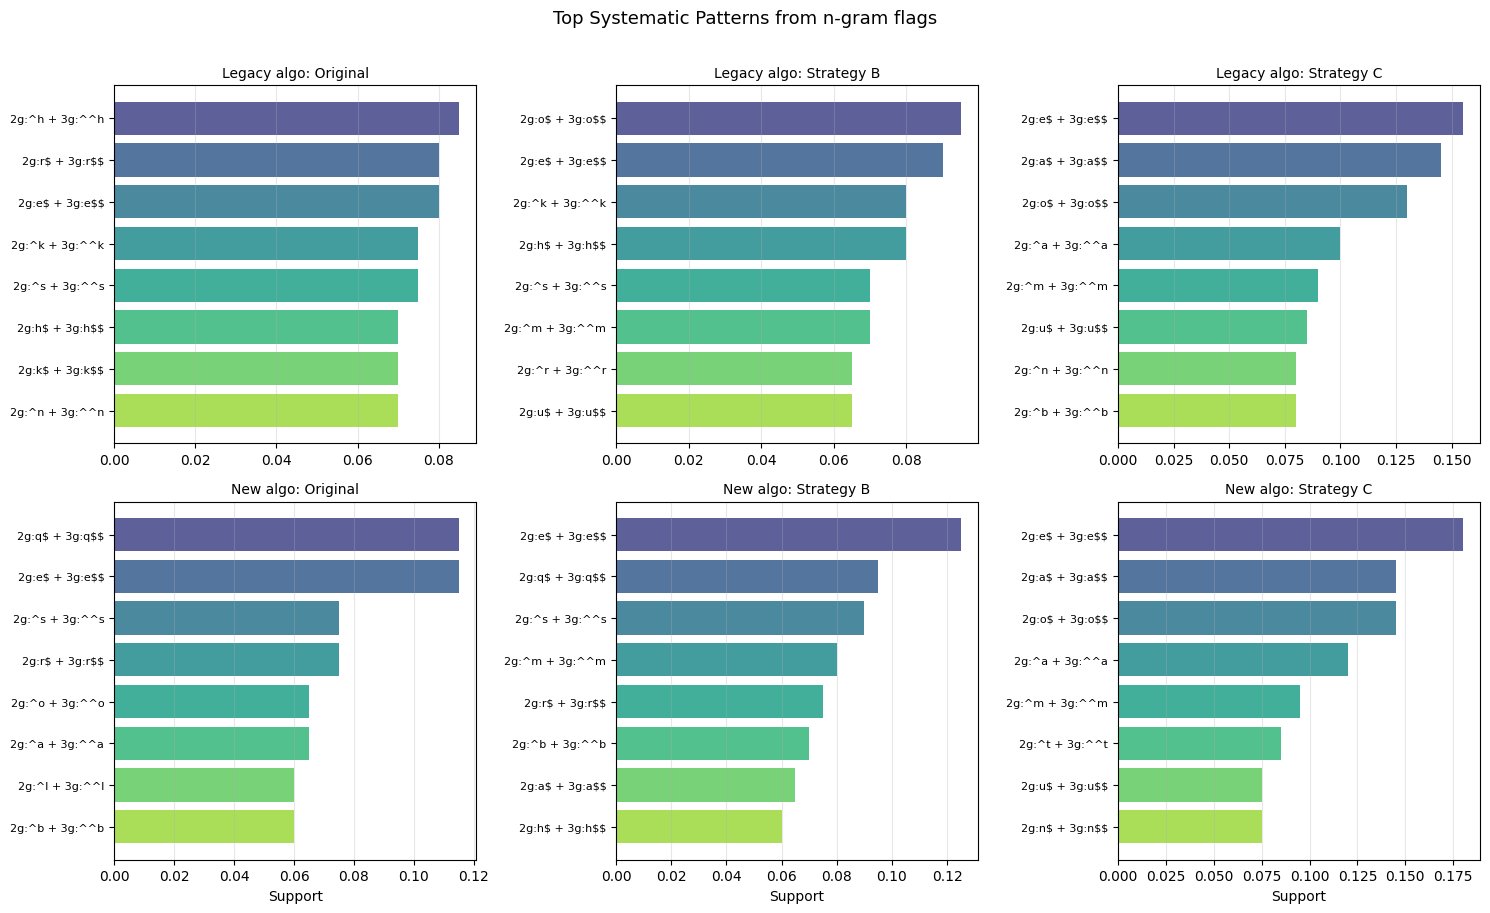

In [20]:
# Bar chart of top patterns per (algo, strategy)
# If both algos have data, show 6 panels (2 algos × 3 strategies)
# If only one algo, show 3 panels for that algo
algos_with_data = sorted(patterns_summary_df["algo"].unique()) if len(patterns_summary_df) else []

if not algos_with_data:
    print("No pattern data available — skipping visualization.")
else:
    n_rows = len(algos_with_data)
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4.5 * n_rows), squeeze=False)

    for row_idx, algo in enumerate(algos_with_data):
        for col_idx, strategy in enumerate(STRATEGIES):
            ax = axes[row_idx, col_idx]
            s_data = patterns_summary_df[(patterns_summary_df["algo"] == algo)
                                          & (patterns_summary_df["strategy"] == strategy)].head(8)
            if s_data.empty:
                ax.text(0.5, 0.5, "(no data)", ha="center", va="center",
                        transform=ax.transAxes)
                ax.set_title(f"{ALGO_DISPLAY[algo]}: {STRATEGY_DISPLAY[strategy]}", fontsize=10)
                continue

            patterns_labels = [str(p)[:30] for p in s_data["pattern"].values]
            supports = s_data["support"].values
            colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(patterns_labels)))

            y_pos = np.arange(len(patterns_labels))
            ax.barh(y_pos, supports, color=colors, alpha=0.85)
            ax.set_yticks(y_pos)
            ax.set_yticklabels(patterns_labels, fontsize=8)
            ax.invert_yaxis()
            ax.set_xlabel("Support" if row_idx == n_rows - 1 else "")
            ax.set_title(f"{ALGO_DISPLAY[algo]}: {STRATEGY_DISPLAY[strategy]}", fontsize=10)
            ax.grid(alpha=0.3, axis="x")

    plt.suptitle("Top Systematic Patterns from n-gram flags",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(DST_DIR / "_systematic_patterns.png", dpi=120, bbox_inches="tight")
    plt.show()

## 8. Headline summary table

In [21]:
summary_rows = []
for algo, method, strategy in product(ALGOS, METHODS, STRATEGIES):
    method_data = aggregates[(aggregates["algo"] == algo)
                              & (aggregates["method"] == method)
                              & (aggregates["strategy"] == strategy)]
    if method_data.empty:
        continue

    flag_set = flag_sets.get((strategy, method, algo), set())

    # Tier correlation — only available for legacy
    if algo == "legacy":
        corr_row = correlation_df[(correlation_df["method"] == method)
                                   & (correlation_df["strategy"] == strategy)]
        rho = corr_row["spearman_rho"].iloc[0] if len(corr_row) > 0 else None
    else:
        rho = None  # not applicable for new algo

    summary_rows.append({
        "algo":               ALGO_DISPLAY[algo],
        "method":             METHOD_DISPLAY[method],
        "strategy":           STRATEGY_DISPLAY[strategy],
        "n_dicts_processed":  len(method_data),
        "total_tokens":       int(method_data["total_tokens"].sum()),
        "total_flagged":      int(method_data["flagged_count"].sum()),
        "unique_flagged":     len(flag_set),
        "mean_flag_rate":     round(method_data["flag_rate"].mean(), 4),
        "tier_correlation":   rho,  # NaN/None for new algo by design
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(DST_DIR / "_headline_summary.csv", index=False)
print("=== Headline Summary ===")
print(summary_df.to_string(index=False))
print(f"\nNote: tier_correlation is reported only for the legacy algorithm. The new")
print(f"algorithm is excluded from tier alignment because tiers were derived from")
print(f"legacy output (see §6 introduction).")
print(f"\nAll comparison outputs in: {DST_DIR.resolve()}")

=== Headline Summary ===
       algo            method   strategy  n_dicts_processed  total_tokens  total_flagged  unique_flagged  mean_flag_rate  tier_correlation
Legacy algo    pyspellchecker   Original                 68       1434567              9               0          0.0000             0.022
Legacy algo    pyspellchecker Strategy B                 68       1434567          28767             100          0.0382             0.703
Legacy algo    pyspellchecker Strategy C                 68       1434567         305903             100          0.2114             0.576
Legacy algo n-gram perplexity   Original                 68       1434567          18503             200          0.0135             0.402
Legacy algo n-gram perplexity Strategy B                 68       1434567          21132             200          0.0155             0.488
Legacy algo n-gram perplexity Strategy C                 68       1434567         120006             200          0.0822             0.505
  

## 9. Reading guide

**The four figures are the meat of this analysis:**

- `_method_agreement.png` answers: do pyspell and n-gram catch the same
  errors, and does that agreement depend on which extraction algorithm
  produced the output? Compare the Jaccard scores across the 6 panels
  (3 strategies × 2 algorithms). Low Jaccard = methods are complementary;
  high Jaccard = redundant. If Jaccard differs across algorithms, it
  suggests the algorithms produce systematically different error
  distributions.

- `_strategy_effect.png` answers: how does flag rate change across
  strategies, separately for each (method × algorithm) combination?
  Lines that slope upward as you move right (Original, B, C) mean
  the vocab tightening increased flag rate for that dict. Comparing
  legacy and new algorithm panels reveals whether the strategy effect
  is consistent across algorithms.

- `_tier_alignment.png` answers: does each method × strategy agree with
  the independent structural quality measurement? Legacy algorithm only.
  Higher Spearman ρ = better alignment between flag rate and tier.
  ρ near 0 = method is measuring something different from structural rules.

- `_systematic_patterns.png` (if available for both algos): which
  systematic error families explain the n-gram flags? Cross-algorithm
  comparison shows whether the two algorithms share the same OCR-derived
  error patterns or have algorithm-specific failure modes.

**The four CSV outputs supplement each figure:**

- `_method_agreement_per_strategy.csv`: exact union/intersection counts
  per (algo, strategy)
- `_strategy_effect_per_method.csv`: flag rate distributions per
  (algo, method, strategy)
- `_tier_alignment_per_pair.csv`: Spearman ρ values with p-values
  (legacy only)
- `_systematic_patterns_summary.csv`: top patterns per (algo, strategy)

**Example CSVs let you inspect concrete tokens:**

- `_examples_method_agreement.csv`: what tokens fall in each agreement
  category, per (algo, strategy)?
- `_examples_strategy_movement.csv`: what tokens moved as strategy
  tightened, per (algo, method)?

**On the scope (68 shared dicts):** This analysis intentionally restricts
to the 68 dictionaries covered by both algorithms (i.e., the dicts present
in the legacy tier file). The 14 dictionaries unique to the new algorithm
are excluded so that cross-algorithm comparisons are made on the same
underlying material. Raw spell-check outputs for those 14 new-only dicts
exist on disk but are not part of this comparison.

**On the vocabulary-sharing caveat:** The vocabularies used by all three
strategies were built from the legacy algorithm's parcor output. When
applied to the new algorithm's output, they evaluate it against a
legacy-derived reference standard. Differences in flag rate between
algorithms reflect both true output-quality differences and any vocabulary
mismatch arising from the legacy origin of the vocab. This is documented
honestly here so the reader can weigh the cross-algorithm comparison
appropriately.